In [7]:
import pandas as pd
from collections import defaultdict
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

# 데이터 개별 처리

In [8]:
key_id_icu = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/key_id_icu.ftr")

df_weight = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/df_weight.ftr")
df_height = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/df_height.ftr")

patient_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/core/parquet/patients.parquet")
admissions_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/core/parquet/admissions.parquet")

In [9]:
key_df = key_id_icu[['subject_id', 'hadm_id', 'stay_id']]

## 1. BMI

In [10]:
df_height = df_height.merge(key_df, on=['subject_id'], how='left')
df_height

,subject_id,height,hadm_id,stay_id
0,10001884.0,158.163390,26184834.0,37510196.0
1,10002428.0,149.895000,23473524.0,35479615.0
2,10002428.0,149.895000,28662225.0,33987268.0
3,10002428.0,149.895000,28662225.0,38875437.0
4,10003400.0,165.660000,20214994.0,32128372.0
...,...,...,...,...
12109,19997367.0,147.876645,21508795.0,36980198.0
12110,19997473.0,157.677500,27787494.0,32134105.0
12111,19998843.0,180.170000,24842066.0,30988867.0
12112,19999287.0,167.111364,20175828.0,35165301.0


In [11]:
df_weight_mean = (df_weight.groupby(['hadm_id', 'stay_id'], as_index=False)['valuenum'].mean().round(2))
df_weight_mean = df_weight_mean.merge(key_df, on=['hadm_id', 'stay_id'], how='left')
df_weight_mean.rename(columns={'valuenum':'weight'}, inplace=True)

df_bmi = df_height.merge(df_weight_mean, on=['hadm_id', 'stay_id'])
df_bmi= df_bmi.drop(columns=['subject_id_y', 'subject_id_x'])
df_bmi['bmi'] = (df_bmi['weight']/((df_bmi['height']/100)**2)).round(1)
df_bmi

,height,hadm_id,stay_id,weight,bmi
0,158.163390,26184834.0,37510196.0,65.00,26.0
1,149.895000,23473524.0,35479615.0,48.46,21.6
2,149.895000,28662225.0,38875437.0,43.21,19.2
3,165.660000,20214994.0,32128372.0,93.10,33.9
4,165.660000,23559586.0,38383343.0,97.99,35.7
...,...,...,...,...,...
11238,147.876645,21508795.0,36980198.0,50.15,22.9
11239,157.677500,27787494.0,32134105.0,63.13,25.4
11240,180.170000,24842066.0,30988867.0,72.82,22.4
11241,167.111364,20175828.0,35165301.0,86.31,30.9


In [12]:
df_bmi['bmi'].describe()

count    11243.000000
mean        28.698550
std          7.617505
min          9.900000
25%         23.700000
50%         27.400000
75%         32.100000
max         94.300000
Name: bmi, dtype: float64

In [13]:
# 이걸 어쩌지? -> BMI binnning
df_bmi[df_bmi['bmi'] > 94]

,height,hadm_id,stay_id,weight,bmi
5311,152.705714,23032853.0,35516732.0,219.8,94.3


### WHO 기준 BMI 분류

| BMI 범위 (kg/m²) | 분류 (Category) |
|------------------|----------------|
| < 18.5           | Underweight    |
| 18.5 – 24.9      | Normal weight  |
| 25.0 – 29.9      | Overweight     |
| 30.0 – 34.9      | Obese Class I  |
| 35.0 – 39.9      | Obese Class II |
| ≥ 40.0           | Obese Class III|


<Axes: >

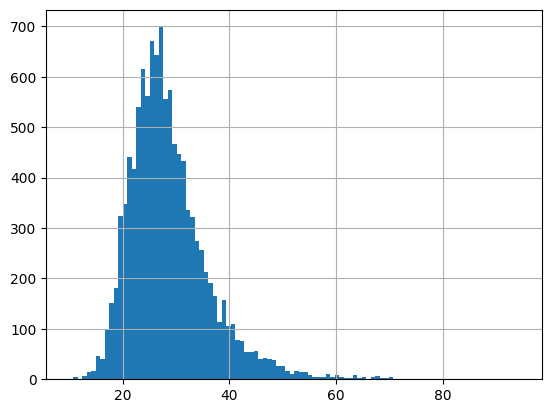

In [14]:
df_bmi['bmi'].hist(bins=100)

In [15]:
def bmi_binning(bmi):
    if pd.isna(bmi):
        return 'unknown'

    elif bmi < 18.5:
        return 'under'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    elif bmi < 35:
        return 'obese1'
    elif bmi < 40:
        return 'obese2'
    else:
        return 'obese3'

In [16]:
df_bmi['bmi_bin'] = df_bmi['bmi'].apply(bmi_binning)
df_bmi = pd.get_dummies(df_bmi, columns=['bmi_bin'], prefix='bmi').astype(int)
df_bmi = df_bmi[['hadm_id', 'stay_id', 'bmi_under', 'bmi_normal', 'bmi_overweight', 'bmi_obese1', 'bmi_obese2', 'bmi_obese3']]

In [17]:
bmi_cols = ['bmi_under', 'bmi_normal', 'bmi_overweight', 'bmi_obese1', 'bmi_obese2', 'bmi_obese3']
df_bmi[bmi_cols].sum()

bmi_under          398
bmi_normal        3345
bmi_overweight    3551
bmi_obese1        2113
bmi_obese2         981
bmi_obese3         855
dtype: int64

In [18]:
df_bmi

,hadm_id,stay_id,bmi_under,bmi_normal,bmi_overweight,bmi_obese1,bmi_obese2,bmi_obese3
0,26184834,37510196,0,0,1,0,0,0
1,23473524,35479615,0,1,0,0,0,0
2,28662225,38875437,0,1,0,0,0,0
3,20214994,32128372,0,0,0,1,0,0
4,23559586,38383343,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...
11238,21508795,36980198,0,1,0,0,0,0
11239,27787494,32134105,0,0,1,0,0,0
11240,24842066,30988867,0,1,0,0,0,0
11241,20175828,35165301,0,0,0,1,0,0


## 2. Insurance, marital status, race

In [19]:
ins_mari_race_df = key_id_icu[['subject_id', 'hadm_id', 'stay_id', 'insurance', 'marital_status', 'race']]
ins_mari_race_df

,subject_id,hadm_id,stay_id,insurance,marital_status,race
0,10001884,26184834.0,37510196.0,Medicare,MARRIED,BLACK/AFRICAN AMERICAN
1,10002428,23473524.0,35479615.0,Medicare,WIDOWED,WHITE
2,10002428,28662225.0,33987268.0,Medicare,WIDOWED,WHITE
3,10002428,28662225.0,38875437.0,Medicare,WIDOWED,WHITE
4,10003400,20214994.0,32128372.0,Medicare,MARRIED,BLACK/AFRICAN AMERICAN
...,...,...,...,...,...,...
14141,19998330,24096838.0,33428243.0,Other,MARRIED,BLACK/AFRICAN AMERICAN
14142,19998843,24842066.0,30988867.0,Other,SINGLE,UNKNOWN
14143,19999287,20175828.0,35165301.0,Medicare,SINGLE,BLACK/AFRICAN AMERICAN
14144,19999442,26785317.0,32336619.0,Medicaid,DIVORCED,WHITE


In [20]:
# insurance one-hot encoding
ins_mari_race_df['insurance'].value_counts()

insurance
Medicare    6890
Other       6185
Medicaid    1071
Name: count, dtype: int64

In [21]:
insurance_onehot = pd.get_dummies(ins_mari_race_df['insurance'], prefix='ins').astype(int)
ins_mari_race_df = pd.concat([ins_mari_race_df, insurance_onehot], axis=1)
ins_mari_race_df

,subject_id,hadm_id,stay_id,insurance,marital_status,race,ins_Medicaid,ins_Medicare,ins_Other
0,10001884,26184834.0,37510196.0,Medicare,MARRIED,BLACK/AFRICAN AMERICAN,0,1,0
1,10002428,23473524.0,35479615.0,Medicare,WIDOWED,WHITE,0,1,0
2,10002428,28662225.0,33987268.0,Medicare,WIDOWED,WHITE,0,1,0
3,10002428,28662225.0,38875437.0,Medicare,WIDOWED,WHITE,0,1,0
4,10003400,20214994.0,32128372.0,Medicare,MARRIED,BLACK/AFRICAN AMERICAN,0,1,0
...,...,...,...,...,...,...,...,...,...
14141,19998330,24096838.0,33428243.0,Other,MARRIED,BLACK/AFRICAN AMERICAN,0,0,1
14142,19998843,24842066.0,30988867.0,Other,SINGLE,UNKNOWN,0,0,1
14143,19999287,20175828.0,35165301.0,Medicare,SINGLE,BLACK/AFRICAN AMERICAN,0,1,0
14144,19999442,26785317.0,32336619.0,Medicaid,DIVORCED,WHITE,1,0,0


In [22]:
# marital_status one-hot encoding
ins_mari_race_df['marital_status'].value_counts()

marital_status
MARRIED     5981
SINGLE      4187
WIDOWED     1876
DIVORCED    1151
Name: count, dtype: int64

In [23]:
marital_onehot = pd.get_dummies(ins_mari_race_df['marital_status'], prefix='mari').astype(int)
ins_mari_race_df = pd.concat([ins_mari_race_df, marital_onehot], axis=1)
ins_mari_race_df

,subject_id,hadm_id,stay_id,insurance,marital_status,race,ins_Medicaid,ins_Medicare,ins_Other,mari_DIVORCED,mari_MARRIED,mari_SINGLE,mari_WIDOWED
0,10001884,26184834.0,37510196.0,Medicare,MARRIED,BLACK/AFRICAN AMERICAN,0,1,0,0,1,0,0
1,10002428,23473524.0,35479615.0,Medicare,WIDOWED,WHITE,0,1,0,0,0,0,1
2,10002428,28662225.0,33987268.0,Medicare,WIDOWED,WHITE,0,1,0,0,0,0,1
3,10002428,28662225.0,38875437.0,Medicare,WIDOWED,WHITE,0,1,0,0,0,0,1
4,10003400,20214994.0,32128372.0,Medicare,MARRIED,BLACK/AFRICAN AMERICAN,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14141,19998330,24096838.0,33428243.0,Other,MARRIED,BLACK/AFRICAN AMERICAN,0,0,1,0,1,0,0
14142,19998843,24842066.0,30988867.0,Other,SINGLE,UNKNOWN,0,0,1,0,0,1,0
14143,19999287,20175828.0,35165301.0,Medicare,SINGLE,BLACK/AFRICAN AMERICAN,0,1,0,0,0,1,0
14144,19999442,26785317.0,32336619.0,Medicaid,DIVORCED,WHITE,1,0,0,1,0,0,0


In [24]:
# race one-hot encoding
ins_mari_race_df['race'].value_counts()

race
WHITE                                        8861
BLACK/AFRICAN AMERICAN                       1441
UNKNOWN                                      1182
OTHER                                         539
WHITE - OTHER EUROPEAN                        294
HISPANIC/LATINO - PUERTO RICAN                238
WHITE - RUSSIAN                               215
ASIAN - CHINESE                               169
ASIAN                                         152
HISPANIC/LATINO - DOMINICAN                   128
BLACK/CAPE VERDEAN                            112
PORTUGUESE                                     91
BLACK/CARIBBEAN ISLAND                         89
UNABLE TO OBTAIN                               83
BLACK/AFRICAN                                  65
ASIAN - SOUTH EAST ASIAN                       50
HISPANIC OR LATINO                             49
AMERICAN INDIAN/ALASKA NATIVE                  48
ASIAN - ASIAN INDIAN                           40
WHITE - EASTERN EUROPEAN                     

In [25]:
race_mapping = {
    'ASIAN': 'ASIAN',
    'ASIAN - ASIAN INDIAN': 'ASIAN',
    'ASIAN - CHINESE': 'ASIAN', 
    'ASIAN - KOREAN': 'ASIAN', 
    'ASIAN - SOUTH EAST ASIAN': 'ASIAN',

    'BLACK/AFRICAN': 'BLACK', 
    'BLACK/AFRICAN AMERICAN': 'BLACK',
    'BLACK/CAPE VERDEAN': 'BLACK',
    'BLACK/CARIBBEAN ISLAND': 'BLACK', 

    'HISPANIC OR LATINO': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - CENTRAL AMERICAN': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - COLUMBIAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - CUBAN': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - DOMINICAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - GUATEMALAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - HONDURAN': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - MEXICAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - PUERTO RICAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - SALVADORAN': 'HISPANIC/LATINO',
    'PORTUGUESE': 'HISPANIC/LATINO',
    'SOUTH AMERICAN': 'HISPANIC/LATINO', 

    'WHITE': 'WHITE', 
    'WHITE - BRAZILIAN': 'WHITE', 
    'WHITE - EASTERN EUROPEAN': 'WHITE', 
    'WHITE - OTHER EUROPEAN': 'WHITE',
    'WHITE - RUSSIAN': 'WHITE', 

    'OTHER': 'OTHER',
    'AMERICAN INDIAN/ALASKA NATIVE': 'OTHER', 
    'MULTIPLE RACE/ETHNICITY': 'OTHER',
    'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'OTHER',

    'UNKNOWN': 'UNKNOWN',
    'UNABLE TO OBTAIN': 'UNKNOWN', 
    'PATIENT DECLINED TO ANSWER': 'UNKNOWN'
}

In [26]:
ins_mari_race_df['race'] = ins_mari_race_df['race'].map(race_mapping)
ins_mari_race_df['race'] = ins_mari_race_df['race'].fillna('OTHER')

ins_mari_race_df['race'] = (
    ins_mari_race_df
    .groupby('subject_id')['race']
    .transform(lambda x: x.mode().iloc[0])
)

check = ins_mari_race_df.groupby('subject_id')['race'].nunique()
assert (check == 1).all()

In [27]:
print("After Race Processing")
ins_mari_race_df['race'].value_counts()

After Race Processing


race
WHITE              9405
BLACK              1715
UNKNOWN            1295
HISPANIC/LATINO     668
OTHER               632
ASIAN               431
Name: count, dtype: int64

In [28]:
race_onehot = pd.get_dummies(ins_mari_race_df['race'], prefix='ethn').astype(int)
ins_mari_race_df = pd.concat([ins_mari_race_df, race_onehot], axis=1)

ins_mari_race_df = ins_mari_race_df.drop(columns=['insurance', 'marital_status','race'])
ins_mari_race_df

,subject_id,hadm_id,stay_id,ins_Medicaid,ins_Medicare,ins_Other,mari_DIVORCED,mari_MARRIED,mari_SINGLE,mari_WIDOWED,ethn_ASIAN,ethn_BLACK,ethn_HISPANIC/LATINO,ethn_OTHER,ethn_UNKNOWN,ethn_WHITE
0,10001884,26184834.0,37510196.0,0,1,0,0,1,0,0,0,1,0,0,0,0
1,10002428,23473524.0,35479615.0,0,1,0,0,0,0,1,0,0,0,0,0,1
2,10002428,28662225.0,33987268.0,0,1,0,0,0,0,1,0,0,0,0,0,1
3,10002428,28662225.0,38875437.0,0,1,0,0,0,0,1,0,0,0,0,0,1
4,10003400,20214994.0,32128372.0,0,1,0,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14141,19998330,24096838.0,33428243.0,0,0,1,0,1,0,0,0,1,0,0,0,0
14142,19998843,24842066.0,30988867.0,0,0,1,0,0,1,0,0,0,0,0,1,0
14143,19999287,20175828.0,35165301.0,0,1,0,0,0,1,0,0,1,0,0,0,0
14144,19999442,26785317.0,32336619.0,1,0,0,1,0,0,0,0,0,0,0,0,1


## 3. Age & Sex

- age 구하는 방법:
age_at_admit=anchor_age+(year(admittime)−anchor_year)

In [29]:
admit_time_df = admissions_df[['subject_id', 'hadm_id', 'admittime']]

age_df = admit_time_df.merge(patient_df, on=['subject_id'], how='left')
age_df['admittime'] = pd.to_datetime(age_df['admittime'])
age_df['age_at_admit'] = (age_df['anchor_age'] + (age_df['admittime'].dt.year - age_df['anchor_year']))

In [30]:
# age_df['is_mismatch'] = age_df['anchor_age'] != age_df['age_at_admit']
# age_df['mismatch_count'] = (age_df['anchor_age'] != age_df['age_at_admit']).astype(int)

# print(f"\n총 불일치 개수: {age_df['is_mismatch'].sum()}")
# print(f"일치율: {(age_df['anchor_age'] == age_df['age_at_admit']).mean() * 100:.2f}%")

In [31]:
age_df = age_df[['subject_id', 'hadm_id','age_at_admit', 'gender']]
age_sex_df = age_df.rename(columns={'age_at_admit':'age'})
age_sex_df

,subject_id,hadm_id,age,gender
0,10000032,22595853,52,F
1,10000032,22841357,52,F
2,10000032,25742920,52,F
3,10000032,29079034,52,F
4,10000068,25022803,19,F
...,...,...,...,...
431226,19999828,25744818,48,F
431227,19999828,29734428,46,F
431228,19999840,21033226,58,M
431229,19999840,26071774,58,M


## 4. Past ICD codes

In [32]:
diagnosis_icd = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/hosp/parquet/diagnoses_icd.parquet")

In [33]:
diag_merged = diagnosis_icd.merge(key_id_icu[['subject_id', 'hadm_id', 'admittime']], on=['subject_id', 'hadm_id'], how='left')
diag_merged.sort_values(by=['subject_id', 'admittime'], inplace=True)

In [34]:
diag_merged

,subject_id,hadm_id,seq_num,icd_code,icd_version,admittime
0,10000032,22595853,1,5723,9,NaT
1,10000032,22595853,2,78959,9,NaT
2,10000032,22595853,3,5715,9,NaT
3,10000032,22595853,4,07070,9,NaT
4,10000032,22595853,5,496,9,NaT
...,...,...,...,...,...,...
4787316,19999987,23865745,7,41401,9,2145-11-02 21:38:00
4787317,19999987,23865745,8,78039,9,2145-11-02 21:38:00
4787318,19999987,23865745,9,0413,9,2145-11-02 21:38:00
4787319,19999987,23865745,10,36846,9,2145-11-02 21:38:00


In [35]:
# ICD9 to ICD10 mapping
# 당장은 불필요

In [36]:
past_history_dict = defaultdict(list)

for subject_id, group in diag_merged.sort_values('admittime').groupby('subject_id'):
    past_codes = set()
    seen_hadm = set()

    for _, row in group.iterrows():
        current_hadm = row['hadm_id']
        icd_code = row['icd_code']

        if current_hadm not in seen_hadm:
            past_history_dict[(subject_id, current_hadm)] = list(past_codes)
            seen_hadm.add(current_hadm)

        past_codes.add(icd_code)

past_history_df = pd.DataFrame([{'subject_id': subject_id,'hadm_id': hadm_id,'past_icd_codes': codes} for (subject_id, hadm_id), codes in past_history_dict.items()])

In [37]:
past_history_df

,subject_id,hadm_id,past_icd_codes
0,10000032,22595853,[]
1,10000032,22841357,"[78959, 496, 29680, 07070, 30981, V1582, 5723,..."
2,10000032,25742920,"[07071, 2875, V08, 2761, 78959, 496, 3051, 296..."
3,10000032,29079034,"[07071, 2875, V08, 2761, 2767, 78959, 496, 305..."
4,10000068,25022803,[]
...,...,...,...
430847,19999828,25744818,[]
430848,19999828,29734428,"[Y929, T8141XA, K632, Z87891, E876, L02211, R1..."
430849,19999840,21033226,[]
430850,19999840,26071774,"[5180, 4019, 51881, 43811, E912, 2724, 9331, 4..."


In [38]:
test = past_history_df.copy()

In [39]:
"""
ICD Filtering
ICD9 기준
- 390-459: Diseases Of The Circulatory System
- 460-519: Diseases Of The Respiratory System

ICD10 기준
- I00-I99: Diseases of the circulatory system
- J00-J99: Diseases of the respiratory system
"""
def has_circulatory(icd_list):
    for code in icd_list:
        code_str = str(code)

        # ICD-10
        if code_str.startswith('I'):
            return 1

        # ICD-9
        if code_str[:3].isdigit():
            num = int(code_str[:3])
            if 390 <= num <= 459:
                return 1
    return 0


def has_respiratory(icd_list):
    for code in icd_list:
        code_str = str(code)

        # ICD-10
        if code_str.startswith('J'):
            return 1

        # ICD-9
        if code_str[:3].isdigit():
            num = int(code_str[:3])
            if 460 <= num <= 519:
                return 1
    return 0

past_history_df['circulatory'] = past_history_df['past_icd_codes'].apply(has_circulatory)
past_history_df['respiratory'] = past_history_df['past_icd_codes'].apply(has_respiratory)

In [40]:
past_history_df

,subject_id,hadm_id,past_icd_codes,circulatory,respiratory
0,10000032,22595853,[],0,0
1,10000032,22841357,"[78959, 496, 29680, 07070, 30981, V1582, 5723,...",0,1
2,10000032,25742920,"[07071, 2875, V08, 2761, 78959, 496, 3051, 296...",0,1
3,10000032,29079034,"[07071, 2875, V08, 2761, 2767, 78959, 496, 305...",0,1
4,10000068,25022803,[],0,0
...,...,...,...,...,...
430847,19999828,25744818,[],0,0
430848,19999828,29734428,"[Y929, T8141XA, K632, Z87891, E876, L02211, R1...",1,1
430849,19999840,21033226,[],0,0
430850,19999840,26071774,"[5180, 4019, 51881, 43811, E912, 2724, 9331, 4...",1,1


In [41]:
past_history_df = past_history_df[['subject_id', 'hadm_id', 'circulatory', 'respiratory']]
past_history_df

,subject_id,hadm_id,circulatory,respiratory
0,10000032,22595853,0,0
1,10000032,22841357,0,1
2,10000032,25742920,0,1
3,10000032,29079034,0,1
4,10000068,25022803,0,0
...,...,...,...,...
430847,19999828,25744818,0,0
430848,19999828,29734428,1,1
430849,19999840,21033226,0,0
430850,19999840,26071774,1,1


In [42]:
hist_cols = ['circulatory', 'respiratory']
past_history_df[hist_cols].sum()

circulatory    197075
respiratory    126759
dtype: int64

# Demographic Dataframe 취합

In [43]:
"""
# 사용해야 하는 df 목록
df_bmi: BMI (식별자: hadm_id, stay_id) - Outlier
ins_mari_race_df: 보험, 결혼 정보, 인종 (식별자: subject_id, hadm_id, stay_id) - one hot encoded
age_sex_df: 나이, 성별 (식별자: subject_id, hadm_id)
past_history_df: 과거 진단 정보 (식별자: subject_id, hadm_id)
"""

ins_mari_race_df.drop(columns=['subject_id', 'stay_id'], inplace=True)
age_sex_df.drop(columns=['subject_id'], inplace=True)
past_history_df.drop(columns=['subject_id'], inplace=True)
df_bmi.drop(columns=['stay_id'], inplace=True)

temp_df1 = key_df.merge(df_bmi, on=['hadm_id'], how='left')
temp_df2 = temp_df1.merge(ins_mari_race_df, on=['hadm_id'], how='left')
temp_df3 = temp_df2.merge(age_sex_df, on=['hadm_id'], how='left')
processed_demo_df = temp_df3.merge(past_history_df, on=['hadm_id'], how='left')

final_demo_df = processed_demo_df.drop_duplicates(subset=['hadm_id'], keep='first')
final_demo_df = final_demo_df.drop(columns=['subject_id', 'stay_id'])
final_demo_df

/tmp/ipykernel_4088260/2485076336.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  past_history_df.drop(columns=['subject_id'], inplace=True)


,hadm_id,bmi_under,bmi_normal,bmi_overweight,bmi_obese1,bmi_obese2,bmi_obese3,ins_Medicaid,ins_Medicare,ins_Other,mari_DIVORCED,mari_MARRIED,mari_SINGLE,mari_WIDOWED,ethn_ASIAN,ethn_BLACK,ethn_HISPANIC/LATINO,ethn_OTHER,ethn_UNKNOWN,ethn_WHITE,age,gender,circulatory,respiratory
0,26184834.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0,0,1,0,0,0,1,0,0,0,0,77,F,0.0,0.0
1,23473524.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,1,81,F,1.0,1.0
2,28662225.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,1,81,F,0.0,0.0
6,20214994.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,0,1,0,0,0,1,0,0,0,0,75,F,0.0,0.0
7,23559586.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,1,0,0,0,1,0,0,0,0,75,F,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18185,24096838.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,1,0,0,0,1,0,0,0,0,72,F,0.0,0.0
18186,24842066.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,1,0,0,1,0,0,0,0,0,1,0,45,M,0.0,0.0
18187,20175828.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,0,0,1,0,0,1,0,0,0,0,77,F,0.0,0.0
18188,26785317.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0,1,0,0,0,0,0,0,0,0,1,43,M,0.0,0.0


In [44]:
final_demo_df

,hadm_id,bmi_under,bmi_normal,bmi_overweight,bmi_obese1,bmi_obese2,bmi_obese3,ins_Medicaid,ins_Medicare,ins_Other,mari_DIVORCED,mari_MARRIED,mari_SINGLE,mari_WIDOWED,ethn_ASIAN,ethn_BLACK,ethn_HISPANIC/LATINO,ethn_OTHER,ethn_UNKNOWN,ethn_WHITE,age,gender,circulatory,respiratory
0,26184834.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0,0,1,0,0,0,1,0,0,0,0,77,F,0.0,0.0
1,23473524.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,1,81,F,1.0,1.0
2,28662225.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,1,81,F,0.0,0.0
6,20214994.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,0,1,0,0,0,1,0,0,0,0,75,F,0.0,0.0
7,23559586.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,1,0,0,0,1,0,0,0,0,75,F,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18185,24096838.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,1,0,0,0,1,0,0,0,0,72,F,0.0,0.0
18186,24842066.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,1,0,0,1,0,0,0,0,0,1,0,45,M,0.0,0.0
18187,20175828.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,0,0,1,0,0,1,0,0,0,0,77,F,0.0,0.0
18188,26785317.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0,1,0,0,0,0,0,0,0,0,1,43,M,0.0,0.0


In [45]:
key_id_icu['hadm_id'].nunique()

12985

In [46]:
# past history가 없는 6행의 환자는 fillna(0)으로 처리함.
final_demo_df['circulatory'] = final_demo_df['circulatory'].fillna(0)
final_demo_df['respiratory'] = final_demo_df['respiratory'].fillna(0)

In [47]:
# gender binary encoding
final_demo_df['gender'] = final_demo_df['gender'].map({'F': 0, 'M': 1})

In [48]:
final_demo_df[['age', 'gender']]

,age,gender
0,77,0
1,81,0
2,81,0
6,75,0
7,75,0
...,...,...
18185,72,0
18186,45,1
18187,77,0
18188,43,1


---

In [ ]:
# age 정규화
scaler = StandardScaler()
final_demo_df['age_z'] = scaler.fit_transform(final_demo_df[['age']])
final_demo_df = final_demo_df.drop(columns=['age'])

In [97]:
final_demo_df

,hadm_id,bmi_under,bmi_normal,bmi_overweight,bmi_obese1,bmi_obese2,bmi_obese3,ins_Medicaid,ins_Medicare,ins_Other,...,ethn_ASIAN,ethn_BLACK,ethn_HISPANIC/LATINO,ethn_OTHER,ethn_UNKNOWN,ethn_WHITE,gender,circulatory,respiratory,age_z
0,26184834.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0,...,0,1,0,0,0,0,0,0.0,0.0,0.701019
1,23473524.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,...,0,0,0,0,0,1,0,1.0,1.0,0.941025
2,28662225.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,...,0,0,0,0,0,1,0,0.0,0.0,0.941025
6,20214994.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,...,0,1,0,0,0,0,0,0.0,0.0,0.581015
7,23559586.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,...,0,1,0,0,0,0,0,1.0,1.0,0.581015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18185,24096838.0,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,...,0,1,0,0,0,0,0,0.0,0.0,0.401011
18186,24842066.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,1,...,0,0,0,0,1,0,1,0.0,0.0,-1.219034
18187,20175828.0,0.0,0.0,0.0,1.0,0.0,0.0,0,1,0,...,0,1,0,0,0,0,0,0.0,0.0,0.701019
18188,26785317.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0,...,0,0,0,0,0,1,1,0.0,0.0,-1.339037


In [98]:
final_demo_df['bmi_normal'].isnull().sum()

1958

In [100]:
# BMI 결측에 해당하는 1958명의 hadm_id는 어떻게 처리할 것인가? -> BMI 결측 여부를 나타내는 전용 컬럼을 넣음.
final_demo_df['observed_bmi'] = (~final_demo_df['bmi_under'].isna()).astype(int)
final_demo_df[bmi_cols] = final_demo_df[bmi_cols].fillna(0)

In [ ]:
final_demo_df = final_demo_df.sort_values(by='hadm_id').reset_index(drop=True)
final_demo_df['hadm_id'] = final_demo_df['hadm_id'].astype(int)
final_demo_df

,hadm_id,bmi_under,bmi_normal,bmi_overweight,bmi_obese1,bmi_obese2,bmi_obese3,ins_Medicaid,ins_Medicare,ins_Other,mari_DIVORCED,mari_MARRIED,mari_SINGLE,mari_WIDOWED,ethn_ASIAN,ethn_BLACK,ethn_HISPANIC/LATINO,ethn_OTHER,ethn_UNKNOWN,ethn_WHITE,gender,circulatory,respiratory,age_z,observed_bmi
0,20001305,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0.0,0.0,1.121030,1
1,20002950,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0.0,0.0,-2.599071,0
2,20004004,0.0,0.0,0.0,1.0,0.0,0.0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,0.0,0.0,-0.199006,1
3,20004357,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0.0,0.0,0.701019,1
4,20004577,0.0,0.0,1.0,0.0,0.0,0.0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0.0,0.0,-1.879052,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12980,29996513,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,0,1,0,0,0,0,0,1,1,0.0,0.0,0.281007,1
12981,29996606,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0.0,0.0,-0.619017,0
12982,29998113,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0.0,0.0,0.761020,1
12983,29998702,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,0.0,0.0,-0.379011,0


In [108]:
final_demo_df.columns

Index(['hadm_id', 'bmi_under', 'bmi_normal', 'bmi_overweight', 'bmi_obese1',
       'bmi_obese2', 'bmi_obese3', 'ins_Medicaid', 'ins_Medicare', 'ins_Other',
       'mari_DIVORCED', 'mari_MARRIED', 'mari_SINGLE', 'mari_WIDOWED',
       'ethn_ASIAN', 'ethn_BLACK', 'ethn_HISPANIC/LATINO', 'ethn_OTHER',
       'ethn_UNKNOWN', 'ethn_WHITE', 'gender', 'circulatory', 'respiratory',
       'age_z', 'observed_bmi'],
      dtype='object')

In [114]:
# 저장
final_demo_df.to_feather("/home/DAHS1/gangmin/my_research/processed/final_demo_df.ftr")